In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [ ]:
df = pd.read_csv(
    'New_train.csv',
    usecols=['Age', 'Fare', 'Survived']
)
df.sample(5)

,Age,Fare,Survived
76,NaN,86.77,0
68,43.0,21.64,0
49,31.9,27.82,0
92,NaN,18.06,1
86,24.4,28.41,1


In [ ]:
X = df.drop(columns=['Survived'])
y = df['Survived']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
X_train['Age_99'] = X_train['Age'].fillna(99)
X_train['Age_minus'] = X_train['Age'].fillna(-1)
X_train['Fare_99'] = X_train['Fare'].fillna(99)
X_train['Fare_minus'] = X_train['Fare'].fillna(-1)

In [ ]:
print('Original Age Variance : ',X_train['Age'].var())
print('Age_99 Variance : ',X_train['Age_99'].var())
print('Age minus Variance : ',X_train['Age_minus'].var())

Original Age Variance :  107.57033691225473
Age_99 Variance :  439.427335443038
Age minus Variance :  164.4526518987341


In [ ]:
print('Original Fare Variance : ',X_train['Fare'].var())
print('Fare_99 Variance : ',X_train['Fare_99'].var())
print('Fare minus Variance : ',X_train['Fare_minus'].var())

Original Fare Variance :  723.5404168231609
Fare_99 Variance :  1070.8896237341767
Fare minus Variance :  743.9782313291141


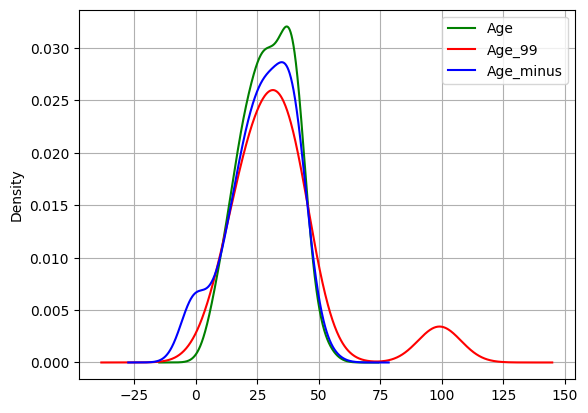

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111)

X_train['Age'].plot(kind= 'kde',ax=ax,color='green')
X_train['Age_99'].plot(kind= 'kde',ax=ax,color='red')
X_train['Age_minus'].plot(kind= 'kde',ax=ax,color='blue')

plt.grid(True)
lines,labels = ax.get_legend_handles_labels()
ax.legend(lines,labels,loc='best')

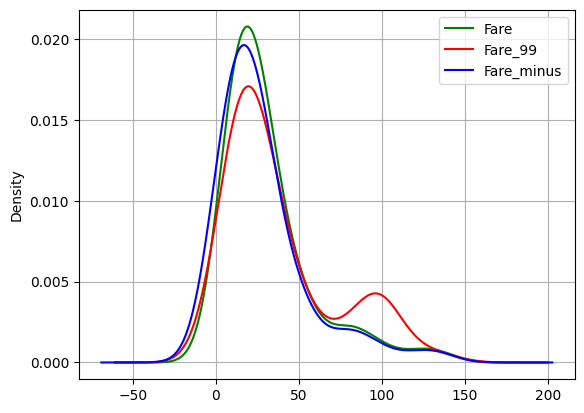

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111)

X_train['Fare'].plot(kind= 'kde',ax=ax,color='green')
X_train['Fare_99'].plot(kind= 'kde',ax=ax,color='red')
X_train['Fare_minus'].plot(kind= 'kde',ax=ax,color='blue')

plt.grid(True)
lines,labels = ax.get_legend_handles_labels()
ax.legend(lines,labels,loc='best')


In [ ]:
X_train.cov()

,Age,Fare,Age_99,Age_minus,Fare_minus,Fare_99
Age,107.570337,14.132697,107.570337,107.570337,11.366634,15.602103
Fare,14.132697,723.540417,-68.692632,48.851578,723.540417,723.540417
Age_99,107.570337,-68.692632,439.427335,-49.325829,-74.286522,-35.147282
Age_minus,107.570337,48.851578,-49.325829,164.452652,47.590060,36.096389
Fare_minus,11.366634,723.540417,-74.286522,47.590060,743.978231,451.737725
Fare_99,15.602103,723.540417,-35.147282,36.096389,451.737725,1070.889624


In [ ]:
X_train.corr()

,Age,Fare,Age_99,Age_minus,Fare_minus,Fare_99
Age,1.000000,0.049411,1.000000,1.000000,0.039289,0.046034
Fare,0.049411,1.000000,-0.124841,0.142976,1.000000,1.000000
Age_99,1.000000,-0.124841,1.000000,-0.183489,-0.129923,-0.051236
Age_minus,1.000000,0.142976,-0.183489,1.000000,0.136055,0.086014
Fare_minus,0.039289,1.000000,-0.129923,0.136055,1.000000,0.506097
Fare_99,0.046034,1.000000,-0.051236,0.086014,0.506097,1.000000


<Axes: >

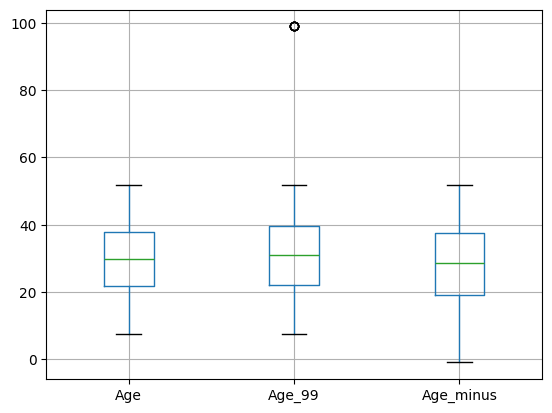

In [ ]:
X_train[['Age','Age_99','Age_minus']].boxplot()

<Axes: >

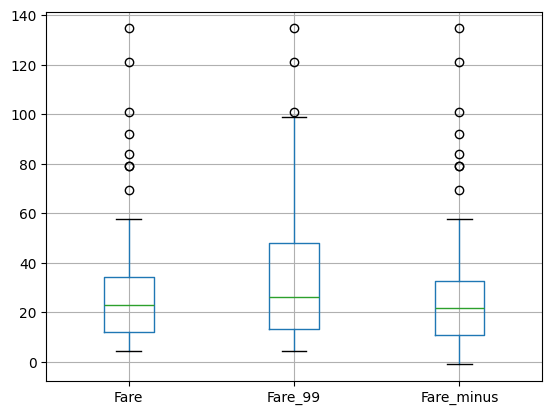

In [ ]:
X_train[['Fare','Fare_99','Fare_minus']].boxplot()

In [ ]:
from sklearn.impute import SimpleImputer

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

imputer1 = SimpleImputer(strategy='constant',fill_value=99)
imputer2 = SimpleImputer(strategy='constant',fill_value=999)

In [ ]:
trf = ColumnTransformer([
    ('Age_imputer',imputer1,['Age']),
    ('Fare_imputer',imputer2,['Fare'])
],remainder='passthrough')

In [ ]:
trf.fit(X_train)

ColumnTransformer(remainder='passthrough',
                  transformers=[('Age_imputer',
                                 SimpleImputer(fill_value=99,
                                               strategy='constant'),
                                 ['Age']),
                                ('Fare_imputer',
                                 SimpleImputer(fill_value=999,
                                               strategy='constant'),
                                 ['Fare'])])

In [ ]:
trf.named_transformers_['Age_imputer'].statistics_

array([99.])

In [ ]:
trf.named_transformers_['Fare_imputer'].statistics_

array([999.])

In [ ]:
X_train=trf.transform(X_train)